# PCA analysis of raw image features

This notebook estimates how much variance in the preprocessed lesion images can be retained by a Principal Component Analysis (PCA) representation before building the final raw-pixel > PCA.

The analysis is deliberately restricted to the **training split** of the selected hypothesis. Validation and test images are not used to fit or select the PCA representation, avoiding information leakage.

Because each 136 × 136 RGB image contains 55,488 raw pixel features, the analysis uses `IncrementalPCA` and a stratified training sample to keep memory usage controlled. The objective is not to generate the final PCA features yet, but to determine whether candidate dimensionalities such as 64, 128, 256 or 512 components retain a reasonable fraction of the image variance.

## 1. Imports and configuration

In [2]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------

from __future__ import annotations

import json
import re
from datetime import datetime
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from PIL import Image
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from skin_lesion_ai.utils.data_utils import (
    load_metadata_parquet,
    load_yaml_config,
    path,
)

In [3]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

HYPOTHESIS = 1

IMAGE_SIZE = 136
RANDOM_STATE = 42

# Maximum number of principal components evaluated in this exploratory study.
MAX_COMPONENTS = 512

# Number of images processed in each IncrementalPCA update.
# Must be >= MAX_COMPONENTS.
PCA_BATCH_SIZE = 1024

# Requested training sample. The effective sample size is automatically
# rounded down to a complete number of PCA batches.
REQUESTED_SAMPLE_SIZE = 10_240

# Candidate dimensionalities to compare.
CANDIDATE_COMPONENTS = [64, 128, 256, 512]

# Variance thresholds reported for reference.
VARIANCE_THRESHOLDS = [0.80, 0.85, 0.90, 0.95]

CONFIG_PATH = "configs/data_config.yaml"
IMAGE_BASENAME = "raw_images_preprocessed"

HYPOTHESIS_CONFIG = {
    1: {
        "target": "target_biopsy",
        "split_filename": "train_split_h1",
    },
    2: {
        "target": "target_malignant",
        "split_filename": "train_split_h2",
    },
}

if HYPOTHESIS not in HYPOTHESIS_CONFIG:
    raise ValueError("HYPOTHESIS must be either 1 or 2.")

if PCA_BATCH_SIZE < MAX_COMPONENTS:
    raise ValueError("PCA_BATCH_SIZE must be >= MAX_COMPONENTS.")

if max(CANDIDATE_COMPONENTS) > MAX_COMPONENTS:
    raise ValueError("Candidate components cannot exceed MAX_COMPONENTS.")

TARGET = HYPOTHESIS_CONFIG[HYPOTHESIS]["target"]
SPLIT_FILENAME = HYPOTHESIS_CONFIG[HYPOTHESIS]["split_filename"]

print(f"Hypothesis: H{HYPOTHESIS}")
print(f"Target: {TARGET}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Raw pixel features per image: {IMAGE_SIZE * IMAGE_SIZE * 3:,}")
print(f"Maximum PCA components: {MAX_COMPONENTS:,}")
print(f"PCA batch size: {PCA_BATCH_SIZE:,}")
print(f"Requested sample size: {REQUESTED_SAMPLE_SIZE:,}")

Hypothesis: H1
Target: target_biopsy
Image size: 136x136
Raw pixel features per image: 55,488
Maximum PCA components: 512
PCA batch size: 1,024
Requested sample size: 10,240


## 2. Load the training split

In [4]:
df_train = load_metadata_parquet(
    stage="processed",
    filename=SPLIT_FILENAME,
    timestamp_flag=True,
)

if "isic_id" not in df_train.columns:
    raise KeyError("Expected 'isic_id' in the training split.")

required_columns = {"isic_id", "patient_id", TARGET}
missing_columns = required_columns.difference(df_train.columns)

if missing_columns:
    raise KeyError(f"Missing required training columns: {sorted(missing_columns)}")

df_train = (
    df_train.loc[:, ["isic_id", "patient_id", TARGET]]
    .rename(columns={"isic_id": "lesion_id"})
    .copy()
)

print(
    f"Training split: {len(df_train):,} lesions | "
    f"{df_train['patient_id'].nunique():,} patients | "
    f"positive rate: {df_train[TARGET].mean():.4%}"
)

df_train.head()

Training split: 305,024 lesions | 784 patients | positive rate: 0.2662%


,lesion_id,patient_id,target_biopsy
0,ISIC_0015670,IP_1235828,0
1,ISIC_0015845,IP_8170065,0
2,ISIC_0015864,IP_6724798,0
3,ISIC_0015902,IP_4111386,0
4,ISIC_0024200,IP_8313778,0


## 3. Select a representative training sample

The PCA is unsupervised, but the exploratory sample is selected with the same target prevalence as the complete training split. Sampling is performed only inside the training set, so it cannot introduce leakage into validation or test.

The effective sample size is rounded down to a multiple of `PCA_BATCH_SIZE`. This guarantees that every `IncrementalPCA.partial_fit()` call receives at least `MAX_COMPONENTS` observations.

In [5]:
max_available = len(df_train)
requested = min(REQUESTED_SAMPLE_SIZE, max_available)

effective_sample_size = (requested // PCA_BATCH_SIZE) * PCA_BATCH_SIZE

if effective_sample_size < PCA_BATCH_SIZE:
    raise ValueError(
        "The training split is too small for the current PCA_BATCH_SIZE. "
        "Reduce PCA_BATCH_SIZE and/or MAX_COMPONENTS."
    )

if effective_sample_size < MAX_COMPONENTS:
    raise ValueError(
        "The effective sample must contain at least MAX_COMPONENTS observations."
    )

if effective_sample_size < len(df_train):
    df_pca_sample, _ = train_test_split(
        df_train,
        train_size=effective_sample_size,
        stratify=df_train[TARGET],
        random_state=RANDOM_STATE,
    )
else:
    df_pca_sample = df_train.copy()

df_pca_sample = df_pca_sample.reset_index(drop=True)

sampling_summary = pd.DataFrame(
    {
        "dataset": ["Full training split", "PCA sample"],
        "lesions": [len(df_train), len(df_pca_sample)],
        "patients": [
            df_train["patient_id"].nunique(),
            df_pca_sample["patient_id"].nunique(),
        ],
        "positive_rate": [
            df_train[TARGET].mean(),
            df_pca_sample[TARGET].mean(),
        ],
    }
)

sampling_summary

,dataset,lesions,patients,positive_rate
0,Full training split,305024,784,0.002662
1,PCA sample,10240,748,0.002637


## 4. Resolve the latest preprocessed image files

In [6]:
def resolve_latest_preprocessed_image_files(
    image_size: int,
    config_path: str | Path = CONFIG_PATH,
    base_filename: str = IMAGE_BASENAME,
) -> tuple[list[Path], Path]:
    """Resolve Parquet files from the latest preprocessed-image manifest."""

    config = load_yaml_config(path(config_path))
    image_dir = path(config["paths"]["interim"]["images"])

    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")

    prefix = f"{Path(base_filename).stem}_{image_size}"
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d{{8}}_\d{{6}})_manifest\.json$")

    candidates: list[tuple[datetime, Path]] = []

    for manifest_path in image_dir.glob(f"{prefix}_*_manifest.json"):
        match = pattern.match(manifest_path.name)

        if not match:
            continue

        try:
            parsed_timestamp = datetime.strptime(
                match.group(1),
                "%Y%m%d_%H%M%S",
            )
        except ValueError:
            continue

        candidates.append((parsed_timestamp, manifest_path))

    if not candidates:
        raise FileNotFoundError(
            f"No preprocessing manifest found for {image_size}x{image_size} "
            f"in {image_dir}."
        )

    manifest_path = max(candidates, key=lambda item: item[0])[1]

    with manifest_path.open("r", encoding="utf-8") as file:
        manifest = json.load(file)

    parquet_paths: list[Path] = []

    for stored_path in manifest.get("files", []):
        candidate = Path(stored_path)

        if candidate.exists():
            parquet_paths.append(candidate)
            continue

        fallback = image_dir / candidate.name

        if fallback.exists():
            parquet_paths.append(fallback)
            continue

        raise FileNotFoundError(
            f"Parquet file listed in manifest was not found: {stored_path}"
        )

    if not parquet_paths:
        raise ValueError("The selected image manifest contains no valid Parquet files.")

    return parquet_paths, manifest_path


image_parquet_paths, image_manifest_path = resolve_latest_preprocessed_image_files(
    image_size=IMAGE_SIZE,
)

print(f"Image manifest: {image_manifest_path}")
print(f"Parquet files: {len(image_parquet_paths)}")

Image manifest: /Users/carlesraichbros/my-image-classifier/data/interim/images/raw_images_preprocessed_136_20260621_082715_manifest.json
Parquet files: 1


## 5. Define memory-safe image decoding and batching

Only the lesions selected for the PCA sample are decoded. The complete image dataset is scanned in Parquet batches, but non-selected images are discarded immediately. Selected JPEG bytes are converted to RGB `float32` arrays in the 0–1 range and flattened to 55,488 features.

Scaling every pixel by the same constant does not alter the PCA explained-variance ratios; the 0–1 conversion is used only for a convenient numerical scale.

In [7]:
def decode_image_to_flat_pixels(
    image_bytes: bytes,
    image_size: int,
) -> np.ndarray:
    """Decode one JPEG image and return a flattened RGB float32 vector."""

    with Image.open(BytesIO(image_bytes)) as image:
        image = image.convert("RGB")

        if image.size != (image_size, image_size):
            raise ValueError(
                f"Expected {image_size}x{image_size}, got "
                f"{image.size[0]}x{image.size[1]}."
            )

        array = np.asarray(image, dtype=np.float32) / 255.0

    return array.reshape(-1)


def iter_selected_pixel_batches(
    parquet_paths: list[Path],
    selected_lesion_ids: set[str],
    image_size: int,
    pca_batch_size: int,
    parquet_batch_size: int = 4096,
):
    """Yield fixed-size raw-pixel batches for selected lesions only."""

    pixel_buffer: list[np.ndarray] = []
    found_ids: set[str] = set()

    for parquet_path in parquet_paths:
        parquet_file = pq.ParquetFile(parquet_path)

        for record_batch in parquet_file.iter_batches(
            batch_size=parquet_batch_size,
            columns=["lesion_id", "image"],
        ):
            batch_df = record_batch.to_pandas()

            selected_df = batch_df.loc[
                batch_df["lesion_id"].isin(selected_lesion_ids),
                ["lesion_id", "image"],
            ]

            for lesion_id, image_bytes in selected_df.itertuples(
                index=False,
                name=None,
            ):
                if lesion_id in found_ids:
                    raise ValueError(f"Duplicated lesion_id found: {lesion_id}")

                found_ids.add(lesion_id)
                pixel_buffer.append(
                    decode_image_to_flat_pixels(
                        image_bytes=image_bytes,
                        image_size=image_size,
                    )
                )

                if len(pixel_buffer) == pca_batch_size:
                    yield np.stack(pixel_buffer).astype(np.float32, copy=False)
                    pixel_buffer = []

    missing_ids = selected_lesion_ids.difference(found_ids)

    if missing_ids:
        examples = sorted(missing_ids)[:10]
        raise ValueError(
            f"{len(missing_ids):,} selected lesions were not found in the "
            f"preprocessed image data. Examples: {examples}"
        )

    if pixel_buffer:
        # This should not happen because the exploratory sample size was
        # selected as a multiple of PCA_BATCH_SIZE.
        raise ValueError(
            f"Final incomplete PCA batch contains {len(pixel_buffer)} images."
        )

## 6. Fit Incremental PCA on training images

In [8]:
selected_ids = set(df_pca_sample["lesion_id"].astype(str))

ipca = IncrementalPCA(
    n_components=MAX_COMPONENTS,
    batch_size=PCA_BATCH_SIZE,
)

n_batches = len(df_pca_sample) // PCA_BATCH_SIZE

progress = tqdm(
    total=n_batches,
    desc="Fitting IncrementalPCA",
    unit="batch",
)

for pixel_batch in iter_selected_pixel_batches(
    parquet_paths=image_parquet_paths,
    selected_lesion_ids=selected_ids,
    image_size=IMAGE_SIZE,
    pca_batch_size=PCA_BATCH_SIZE,
):
    ipca.partial_fit(pixel_batch)
    progress.update(1)

progress.close()

print("PCA fitting completed.")
print(f"Components fitted: {ipca.n_components_:,}")
print(f"Training images used: {len(df_pca_sample):,}")

Fitting IncrementalPCA:   0%|          | 0/10 [00:00<?, ?batch/s]

PCA fitting completed.
Components fitted: 512
Training images used: 10,240


## 7. Explained variance by number of components

In [9]:
explained_variance_ratio = ipca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

candidate_rows = []

for n_components in CANDIDATE_COMPONENTS:
    candidate_rows.append(
        {
            "n_components": n_components,
            "cumulative_explained_variance": cumulative_variance[n_components - 1],
        }
    )

df_candidate_variance = pd.DataFrame(candidate_rows)

df_candidate_variance

,n_components,cumulative_explained_variance
0,64,0.938459
1,128,0.950081
2,256,0.961369
3,512,0.972252


In [10]:
threshold_rows = []

for threshold in VARIANCE_THRESHOLDS:
    reached = np.flatnonzero(cumulative_variance >= threshold)

    if len(reached) > 0:
        components_required = int(reached[0] + 1)
        status = "Reached"
    else:
        components_required = None
        status = f"Not reached within {MAX_COMPONENTS} components"

    threshold_rows.append(
        {
            "variance_threshold": threshold,
            "components_required": components_required,
            "status": status,
        }
    )

df_variance_thresholds = pd.DataFrame(threshold_rows)

df_variance_thresholds

,variance_threshold,components_required,status
0,0.80,2,Reached
1,0.85,4,Reached
2,0.90,10,Reached
3,0.95,128,Reached


## 8. Cumulative explained variance curve

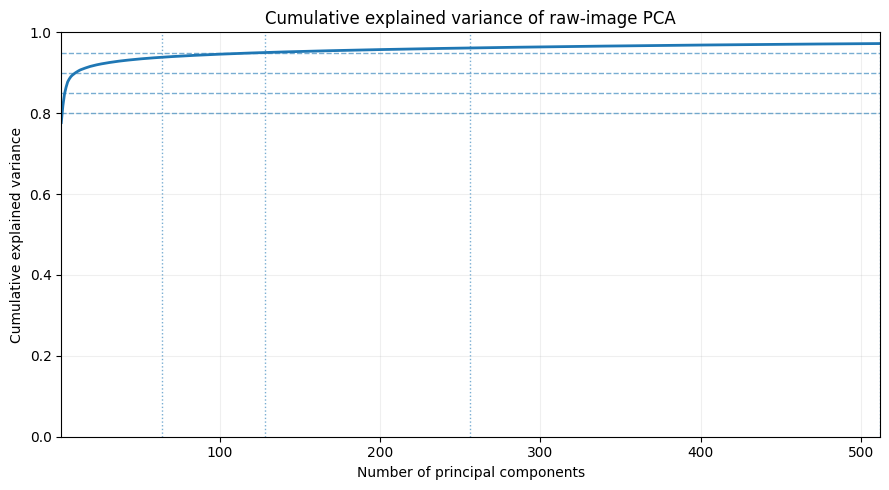

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

component_axis = np.arange(1, MAX_COMPONENTS + 1)

ax.plot(
    component_axis,
    cumulative_variance,
    linewidth=2,
)

for threshold in VARIANCE_THRESHOLDS:
    ax.axhline(
        y=threshold,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

for n_components in CANDIDATE_COMPONENTS:
    ax.axvline(
        x=n_components,
        linestyle=":",
        linewidth=1,
        alpha=0.6,
    )

ax.set_title("Cumulative explained variance of raw-image PCA")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_xlim(1, MAX_COMPONENTS)
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 9. Summary for component selection

In [12]:
summary = df_candidate_variance.copy()
summary["cumulative_explained_variance_pct"] = (
    100 * summary["cumulative_explained_variance"]
)

summary = summary[
    [
        "n_components",
        "cumulative_explained_variance",
        "cumulative_explained_variance_pct",
    ]
]

summary

,n_components,cumulative_explained_variance,cumulative_explained_variance_pct
0,64,0.938459,93.845924
1,128,0.950081,95.008098
2,256,0.961369,96.136901
3,512,0.972252,97.225228


### Interpretation

The final number of PCA components should be selected after inspecting both tables and the cumulative explained-variance curve.

A fixed 90% explained-variance requirement should **not** be imposed automatically. If 90% is reached with a moderate number of components, that threshold can provide a simple justification. If it is not reached within 512 components, the result indicates that raw image variance is highly distributed across dimensions; in that case, a pragmatic fixed representation such as 256 or 512 components may be preferable for the XGBoost baseline.

This notebook estimates the dimensionality on a representative **training-only sample**. The final PCA-generation script should then:

1. fit the PCA exclusively on the training data of the selected hypothesis;
2. transform training, validation and test images using that fitted PCA;
3. save the transformed features and the fitted PCA object;
4. keep H1 and H2 PCA fits independent, because their training populations differ.